## Google Colab / GPU setup

In [1]:
# Detect Colab if present
try:
    from google.colab import drive
    COLAB = True
    print('Note: using Google Colab')
except:
    print('Note: not using Google Colab')
    COLAB = False

# Use GPU or MPS (Apple) if available
import torch
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Note: not using Google Colab
Using device: mps


## FTIR Images Dataset

In [46]:
import os
from PIL import Image
from torch.utils.data import Dataset

# Dataset class to retrieve malignant and non-malignant FTIR images
class FTIRDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.data = []
        self.load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path)
        return img, label
    
    def load_data(self):
        for label, sub_dir in enumerate(['non_malignant', 'malignant']):
            full_path = os.path.join(self.root_dir, sub_dir)
            images = [(os.path.join(full_path, img), label) for img in os.listdir(full_path) if img.endswith('.tif')]
            self.data.extend(images)
            

# Dataset: 78 FTIR core images total (65 malignant, 13 non-malignant)
full_dataset = FTIRDataset(root_dir='../dataset/ftir_core_all_images')
print(f'Dataset samples: {len(full_dataset)}')

Dataset samples: 78


In [47]:
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
BATCH_SIZE = 8

# Augment training images (due to small set size)
def get_train_transform():
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_WIDTH, IMAGE_HEIGHT)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(90, fill=(0, 0, 0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_transform


# Test transform (no augmentation)
def get_test_transform():
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_WIDTH, IMAGE_HEIGHT)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return test_transform


# Applies augmentations to dataset (necessary to ensure training subset is augmented but not validation subset in cross-validation later)
class WrapperDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        
        if self.transform:
            img = self.transform(img)

        return img, label


augmented_dataset = WrapperDataset(base_dataset=full_dataset, transform=get_train_transform())
dataloader = DataLoader(augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Check first batch as an example
for images, labels in dataloader:
    print(f"Batch shape: {images.shape}, Batch labels: {labels}")
    break

Batch shape: torch.Size([8, 3, 224, 224]), Batch labels: tensor([1, 0, 1, 1, 1, 1, 1, 0])


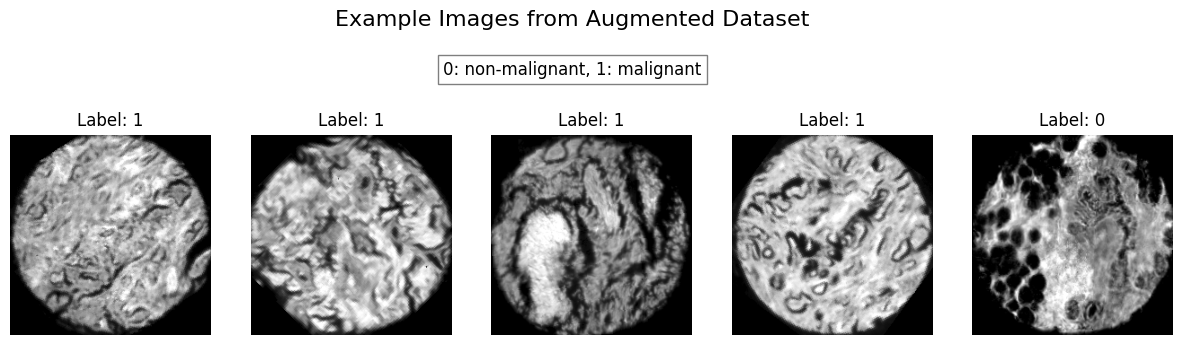

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Display random augmented images from the dataset 
def display_images(dataset, num_images=5, title=''):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    fig.subplots_adjust(top=0.95)
    indices = random.sample(range(len(dataset)), num_images) 

    for i, ax in enumerate(axes):
        img, label = dataset[indices[i]]
        img = img.permute(1, 2, 0).numpy()
        img = img[:, :, 0] 

        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f'Label: {label}')

    legend_text = '0: non-malignant, 1: malignant'
    fig.text(0.5, 0.85, legend_text, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()
    

display_images(augmented_dataset, title='Example Images from Augmented Dataset')

## Model Initialisation

A pretrained Resnet-18 model was used (with ImageNet weights) to achieve better results via transfer learning, due to the small dataset size (78 images total). 

Cross-entropy loss function was used with class weights set to [0.9, 0.1] for non-malignant class(0) and malignant class (1) respectively, to deal with the class imbalance at the core level (65 malignant images and 13 non-malignant images).

In [49]:
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchvision import models
from torchvision.models import ResNet18_Weights

def init_model():
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2) # binary classification
    
    for name, param in model.named_parameters():
        if 'fc' in name: # unfreeze final classification layer
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    model.to(device)
    return model

def init_optimiser(model, learning_rate=3e-4):
    optimiser = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    return optimiser

def init_loss_fn():
    weights = torch.tensor([0.85, 0.15]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    return loss_fn


model = init_model()
#summary(model, input_size=(8, 3, 224, 224))